Exercise 1: Finite-precision arithmetic

Part_1 A 64 bits word size is commonly referred to as double precision,We would like to know: what is the roundoff error, what is the largest number, and what is the smallest number that can be represented in the computer?

In [367]:
import sys
sys.float_info

sys.float_info(max=1.7976931348623157e+308, max_exp=1024, max_10_exp=308, min=2.2250738585072014e-308, min_exp=-1021, min_10_exp=-307, dig=15, mant_dig=53, epsilon=2.220446049250313e-16, radix=2, rounds=1)

max     = 1.7976931348623157e+308
min     = 2.2250738585072014e-308
epsilon = 2.220446049250313e-16

Part_2   
0.125 = 125/1000 = 1/8 =1/2^3 a good binary 0.001
and 0.25 = 1/4 = 1/2^2 also can write in binary 0.01
0.125+ 0.25 = 0.001 + 0.010 = 0.011
1/4 + 1/8 = 3/8=0.375
But! 
0.1 = 1/10 =1/(2*5)its representation keeps going forever computer cannot store infinite many digits so it cuts it down.same as 0.2 
so 0.1 +0.2 = 0.300000004
and therefore 0.1+0.2==0.3 is found FALSE.


Part_3
No we wont use == as it can come out false even though it isnt and it comes out false dure to a tiny difference. we can use math.isclose()

In [368]:
import math

a = 0.1 + 0.2
b = 0.3

print(a == b)
print(math.isclose(a, b))

False
True


Exercise 2: Get up to speed with NumPy

In [369]:
import numpy as np
import matplotlib.pyplot as plt

Exercise3: Build finite-difference tools

In [370]:
def damped_angle(t, A=0.6, gamma=0.05, omega0=np.pi):
    return A*np.exp(-gamma*t)*np.cos(omega0*t)

In [371]:
def damped_velocity(t, A=0.6, gamma=0.05, omega0=np.pi):
    return -A*np.exp(-gamma*t) * (gamma*np.cos(omega0*t) + omega0*np.sin(omega0*t))

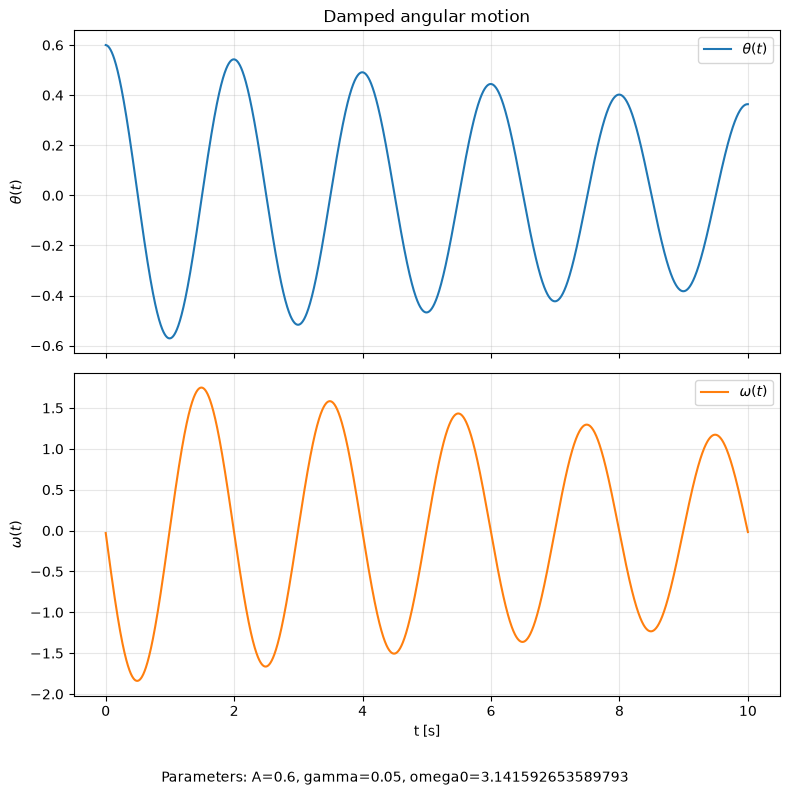

In [372]:
A = 0.6
gamma = 0.05
omega0 = np.pi
t = np.linspace(0, 10, 2000)

theta = A * np.exp(-gamma * t) * np.cos(omega0 * t)
omega = damped_velocity(t, A=A, gamma=gamma, omega0=omega0)

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t, theta, label=r'$\theta(t)$')
axes[0].set_ylabel(r'$\theta(t)$')
axes[0].set_title(r'Damped angular motion')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(t, omega, label=r'$\omega(t)$', color='C1')
axes[1].set_xlabel('t [s]')
axes[1].set_ylabel(r'$\omega(t)$')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.text(0.5, 0.02,
         f'Parameters: A={A}, gamma={gamma}, omega0={omega0}',
         ha='center', va='center', fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [373]:
def forward_diff(y,h):
    y = np.asarray(y, dtype=float)
    return (y[1:] - y[:-1]) / h

In [374]:
def central_diff(y, h):
    y = np.asarray(y, dtype=float)
    return (y[2:] - y[:-2]) / (2 * h)


<h1> Exercise 4: Automatic for the people </h1>

<h3>4.1 A small class first</h1>


In [375]:
import numpy as np
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def distance_from_origin(self):
        return np.sqrt(self.x**2 + self.y**2)

    def move(self, dx, dy):
        self.x += dx
        self.y += dy

point1 = Point(1,1)
point2 = Point(2,2)

point1.distance_from_origin()
point2.distance_from_origin()

point2.move(2,2)
print(point2.x,point2.y)

4 4


The class holds the data inside Point as x and y, and the operations that keep the class together are distance_from_origin which calculates distance from point to (0,0) and move which updates the coordinates of the point.

<h3>  4.2 A specialized application: automatic differentiation </h1>

In [376]:
class Dual:
    """Store a function value and its derivative."""
    def __init__(self, value, derivative=0.0):
        self.value = value
        self.derivative = derivative
        
    def __repr__(self):
        return f"Dual(value={self.value}, derivative={self.derivative})"

x = Dual(3, 1)
c = Dual(3)
print(x,c)

Dual(value=3, derivative=1) Dual(value=3, derivative=0.0)


x = Dual(3, 1) specifically puts 1 as the derivative to x, because the __init__ method takes a value and the derivative. Since c = Dual(3) only gets passed a value, it automatically assigns the default derivative value of 0,0. Additionally x represents a variable whose derivative is $(\frac{dx}{dx} = 1)$ while c is just a constant whose derivative is 0

The data stored inside each Dual object is: self.value and self.derivative

<h3>  4.3 Addition and subtraction </h1>

In [377]:
class Dual:
    """Store a function value and its derivative."""
    def __init__(self, value, derivative=0.0):
        self.value = value
        self.derivative = derivative
        
    def __repr__(self):
        return f"Dual(value={self.value}, derivative={self.derivative})"
    
    def __add__(self, other):
        return Dual(self.value + other.value, self.derivative + other.derivative)
    
    def __sub__(self, other):
        return Dual(self.value - other.value, self.derivative - other.derivative)

    def __neg__(self):
        return Dual(self.value * (-1), self.derivative * (-1))

u = Dual(1,2)
v = Dual(3,4)
print(u+v)
print(u-v)
print(-u)


Dual(value=4, derivative=6)
Dual(value=-2, derivative=-2)
Dual(value=-1, derivative=-2)
